In [1]:
import os
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt 
import xarray as xr
import pandas as pd
import datetime

def wr(txt):
    w=open('日志2.log','a')
    w.write(txt)
    w.close()
http_proxy = "socks://127.0.0.1:3248"
http_proxy = "socks://127.0.0.1:3248"
http_proxy = "socks://127.0.0.1:3248"
https_proxy = "socks://127.0.0.1:3248"
os.environ['HTTP_PROXY'] = http_proxy
os.environ['HTTPS_PROXY'] = https_proxy

# x 1499:1:2499
# y 949:1:1399
# z 0:1:33

In [2]:
with open(r'D:\OneDrive\heat_budget\MHW_HB\need3.txt','r') as f:
    a=f.readlines()
def getdat(s):
    return s.split()[0].split("'")[1][:7].replace('-','_')
temp_add = np.unique(np.array(sorted(map(getdat,a))))
print(temp_add)

['1994_04' '1996_02' '1996_10' '1996_12' '1997_06' '1997_08' '1997_09'
 '1998_02' '1998_04' '1998_06' '1999_02' '2000_02' '2000_04' '2000_05'
 '2000_12' '2001_02' '2003_03' '2004_02' '2004_06' '2004_11' '2005_02'
 '2005_04' '2005_11' '2006_02' '2008_01' '2008_03' '2008_06' '2013_03'
 '2014_02' '2014_05' '2015_05' '2016_03' '2016_05' '2016_11' '2017_01'
 '2017_05' '2017_07' '2021_01' '2021_03' '2021_07' '2021_09' '2021_12'
 '2022_10' '2022_12']


In [4]:
def r2(s):
    return s[:-2]
wr(f'{datetime.datetime.now()}: Start Download : \n')
per=[
    [0,11],
    [11,22],
    [22,33]
]
ts=pd.date_range('19930101','20221231',freq='D')
num=0
print(temp_add)
for i in temp_add[num:]:
    print(temp_add[num])
    ml=ts[(ts.year==int(i.split("_")[0]))&(ts.month==int(i.split("_")[1]))].shape[0]-1
    
    # wr(f'{datetime.datetime.now()}:   MLD Download : ocean_mld_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc \n')
    # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_mld_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?mld[0:1:{ml}][949:1:1399][1499:1:2499]')
    # das.to_netcdf(rf'E:\OceanData\Bran\mld\ocean_mld_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    # wr(rf'{datetime.datetime.now()}:   MLD Down End : Save To E:\OceanData\Bran\mld\ocean_mld_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    # wr('\n')
    
    wr(f'{datetime.datetime.now()}:  TEMP Download : ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy \n')
    # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?temp[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    # das.to_netcdf(rf'E:\OceanData\Bran\temp\ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    temp=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?temp[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['temp']) for j in per],axis=1))
    np.save(rf'F:\OceanData\Bran\temp3\ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy',temp)
    wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\temp3\ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy')
    wr('\n')
    
    # wr(f'{datetime.datetime.now()}:  U Download : ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy \n')
    # #das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?u[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    # #das.to_netcdf(rf'E:\OceanData\Bran\u\ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    # us=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?u[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['u']) for j in per],axis=1))
    # np.save(rf'F:\OceanData\Bran\u3\ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy',us)
    # wr(rf'{datetime.datetime.now()}:  U Down End : Save To E:\OceanData\Bran\u3\ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy')
    # wr('\n')
    
    # wr(f'{datetime.datetime.now()}:  TEMP Download : ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy \n')
    # # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?v[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    # # das.to_netcdf(rf'E:\OceanData\Bran\v\ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    # vs=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?v[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['v']) for j in per],axis=1))
    # np.save(rf'E:\OceanData\Bran\v\ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy',vs)
    # wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\v\ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy')
    # wr('\n')
    print(num)
    num+=1

    
    

['1994_04' '1996_02' '1996_10' '1996_12' '1997_06' '1997_08' '1997_09'
 '1998_02' '1998_04' '1998_06' '1999_02' '2000_02' '2000_04' '2000_05'
 '2000_12' '2001_02' '2003_03' '2004_02' '2004_06' '2004_11' '2005_02'
 '2005_04' '2005_11' '2006_02' '2008_01' '2008_03' '2008_06' '2013_03'
 '2014_02' '2014_05' '2015_05' '2016_03' '2016_05' '2016_11' '2017_01'
 '2017_05' '2017_07' '2021_01' '2021_03' '2021_07' '2021_09' '2021_12'
 '2022_10' '2022_12']
1994_04
0
1996_02
1
1996_10
2
1996_12
3
1997_06
4
1997_08
5
1997_09
6
1998_02
7
1998_04
8
1998_06
9
1999_02


In [4]:
t=pd.date_range('19930101','20221231',freq='M')
ts=pd.date_range('19930101','20221231',freq='D')


def vw(li):
    sep=len(li)//5
    for j in range(5):
        w=open(f'VDOW{j:02d}.sh','w',newline='\n')
        for i in li[j*sep:j*sep+sep]:
            lis=i.split('_')
            ml=ts[(ts.year==int(lis[0]))&(ts.month==int(lis[1]))].shape[0]-1
            #w.write(f'\necho "$(date): Starting  ocean_v_{lis[0]}_{int(lis[1]):02d}_{lis[-1]}.nc" \n')
            #w.write(f'ncks -O -4 -L 8 -P -s 4M https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{lis[0]}_{int(lis[1]):02d}.nc?v[0:1:{ml}][0:1:11][949:1:1399][1499:1:2499] /lustre/home/yuhanxue/data/BRAN/v2/ocean_v_{lis[0]}_{int(lis[1]):02d}_1.nc')
            w.write(f'\necho "$(date): Starting  ocean_v_{lis[0]}_{int(lis[1]):02d}_{lis[-1]}.nc" \n')
            w.write(f'ncks -O -4 -L 8 -P -s 4M https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{lis[0]}_{int(lis[1]):02d}.nc?v[0:1:{ml}][11:1:22][949:1:1399][1499:1:2499] /lustre/home/yuhanxue/data/BRAN/v2/ocean_v_{lis[0]}_{int(lis[1]):02d}_2.nc')
            w.write(f'\necho "$(date): Starting  ocean_v_{lis[0]}_{int(lis[1]):02d}_{lis[-1]}.nc" \n')
            w.write(f'ncks -O -4 -L 8 -P -s 4M https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{lis[0]}_{int(lis[1]):02d}.nc?v[0:1:{ml}][22:1:33][949:1:1399][1499:1:2499] /lustre/home/yuhanxue/data/BRAN/v2/ocean_v_{lis[0]}_{int(lis[1]):02d}_3.nc')
            #print(ml)
        w.close()
    w=open(f'VDOW{j+1:02d}.sh','w',newline='\n')
    for i in li[j*sep+sep:]:
        lis=i.split('_')
        ml=ts[(ts.year==int(lis[0]))&(ts.month==int(lis[1]))].shape[0]-1
        #w.write(f'\necho "$(date): Starting  ocean_v_{lis[0]}_{int(lis[1]):02d}_{lis[-1]}.nc" \n')
        #w.write(f'ncks -O -4 -L 8 -P -s 4M https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{lis[0]}_{int(lis[1]):02d}.nc?v[0:1:{ml}][0:1:11][949:1:1399][1499:1:2499] /lustre/home/yuhanxue/data/BRAN/v2/ocean_v_{lis[0]}_{int(lis[1]):02d}_1.nc')
        w.write(f'\necho "$(date): Starting  ocean_v_{lis[0]}_{int(lis[1]):02d}_{lis[-1]}.nc" \n')
        w.write(f'ncks -O -4 -L 8 -P -s 4M https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{lis[0]}_{int(lis[1]):02d}.nc?v[0:1:{ml}][11:1:22][949:1:1399][1499:1:2499] /lustre/home/yuhanxue/data/BRAN/v2/ocean_v_{lis[0]}_{int(lis[1]):02d}_2.nc')
        w.write(f'\necho "$(date): Starting  ocean_v_{lis[0]}_{int(lis[1]):02d}_{lis[-1]}.nc" \n')
        w.write(f'ncks -O -4 -L 8 -P -s 4M https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{lis[0]}_{int(lis[1]):02d}.nc?v[0:1:{ml}][22:1:33][949:1:1399][1499:1:2499] /lustre/home/yuhanxue/data/BRAN/v2/ocean_v_{lis[0]}_{int(lis[1]):02d}_3.nc')
            #print(ml)
    w.close()  

vw(temp_add)

In [ ]:
f=open(r'D:\OneDrive\heat_budget\MHW_HB\needs.txt','r')
a=f.readlines()
f.close()
def getdat(s):
    return s.split('.')[0].split('_')[-3]+'_'+s.split('.')[0].split('_')[-2]
temp_add=list(map(getdat,a))
def r2(s):
    return s[:-2]
wr(f'{datetime.datetime.now()}: Start Download : \n')
per=[
    [0,11],
    [11,22],
    [22,33]
]
ts=pd.date_range('19930101','20221231',freq='D')
num=42
print(temp_add)
for i in temp_add[num:]:
    print(temp_add[num])
    ml=ts[(ts.year==int(i.split("_")[0]))&(ts.month==int(i.split("_")[1]))].shape[0]-1
    
    # wr(f'{datetime.datetime.now()}:   MLD Download : ocean_mld_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc \n')
    # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_mld_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?mld[0:1:{ml}][949:1:1399][1499:1:2499]')
    # das.to_netcdf(rf'E:\OceanData\Bran\mld\ocean_mld_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    # wr(rf'{datetime.datetime.now()}:   MLD Down End : Save To E:\OceanData\Bran\mld\ocean_mld_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    # wr('\n')
    
    wr(f'{datetime.datetime.now()}:  TEMP Download : ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy \n')
    # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?temp[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    # das.to_netcdf(rf'E:\OceanData\Bran\temp\ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    temp=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?temp[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['temp']) for j in per],axis=1))
    np.save(rf'F:\OceanData\Bran\temp2\ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy',temp)
    wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\temp2\ocean_temp_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy')
    wr('\n')
    
    # wr(f'{datetime.datetime.now()}:  TEMP Download : ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy \n')
    # #das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?u[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    # #das.to_netcdf(rf'E:\OceanData\Bran\u\ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    # us=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?u[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['u']) for j in per],axis=1))
    # np.save(rf'F:\OceanData\Bran\u\ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy',us)
    # wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\u\ocean_u_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy')
    # wr('\n')
    
    # wr(f'{datetime.datetime.now()}:  TEMP Download : ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy \n')
    # # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?v[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    # # das.to_netcdf(rf'E:\OceanData\Bran\v\ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc')
    # vs=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.nc?v[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['v']) for j in per],axis=1))
    # np.save(rf'E:\OceanData\Bran\v\ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy',vs)
    # wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\v\ocean_v_{i.split("_")[0]}_{int(i.split("_")[1]):02d}.npy')
    # wr('\n')
    print(num)
    num+=1

    
    

In [ ]:

t=pd.date_range('19930101','20221231',freq='M')
ts=pd.date_range('19930101','20221231',freq='D')
per=[
    [0,16],
    [16,33]
]
num=131
nums=num
wr(f'{datetime.datetime.now()}: Start Download : \n')
for i in t[num:200]:
    ml=ts[(ts.year==i.year)&(ts.month==i.month)].shape[0]-1
    
    # wr(f'{datetime.datetime.now()}:   MLD Download : ocean_mld_{i.year}_{i.month:02d}.nc \n')
    # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_mld_{i.year}_{i.month:02d}.nc?mld[0:1:{ml}][949:1:1399][1499:1:2499]')
    # das.to_netcdf(rf'E:\OceanData\Bran\mld\ocean_mld_{i.year}_{i.month:02d}.nc')
    # wr(rf'{datetime.datetime.now()}:   MLD Down End : Save To E:\OceanData\Bran\mld\ocean_mld_{i.year}_{i.month:02d}.nc')
    # wr('\n')
    
    wr(f'{datetime.datetime.now()}:  TEMP Download : ocean_temp_{i.year}_{i.month:02d}.npy \n')
    # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_{i.year}_{i.month:02d}.nc?temp[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    # das.to_netcdf(rf'E:\OceanData\Bran\temp\ocean_temp_{i.year}_{i.month:02d}.nc')
    temp=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_{i.year}_{i.month:02d}.nc?temp[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['temp']) for j in per],axis=1))
    np.save(rf'E:\OceanData\Bran\temp\ocean_temp_{i.year}_{i.month:02d}.npy',temp)
    wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\temp\ocean_temp_{i.year}_{i.month:02d}.npy')
    wr('\n')
    
    wr(f'{datetime.datetime.now()}:  TEMP Download : ocean_u_{i.year}_{i.month:02d}.npy \n')
    #das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_u_{i.year}_{i.month:02d}.nc?u[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    #das.to_netcdf(rf'E:\OceanData\Bran\u\ocean_u_{i.year}_{i.month:02d}.nc')
    us=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_u_{i.year}_{i.month:02d}.nc?u[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['u']) for j in per],axis=1))
    np.save(rf'E:\OceanData\Bran\u\ocean_u_{i.year}_{i.month:02d}.npy',us)
    wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\u\ocean_u_{i.year}_{i.month:02d}.npy')
    wr('\n')
    
    wr(f'{datetime.datetime.now()}:  TEMP Download : ocean_v_{i.year}_{i.month:02d}.npy \n')
    # das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{i.year}_{i.month:02d}.nc?v[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    # das.to_netcdf(rf'E:\OceanData\Bran\v\ocean_v_{i.year}_{i.month:02d}.nc')
    vs=np.array(np.concatenate([np.array(xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_v_{i.year}_{i.month:02d}.nc?v[0:1:{ml}][{j[0]}:1:{j[1]}][949:1:1399][1499:1:2499]')['v']) for j in per],axis=1))
    np.save(rf'E:\OceanData\Bran\v\ocean_v_{i.year}_{i.month:02d}.npy',vs)
    wr(rf'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\v\ocean_v_{i.year}_{i.month:02d}.npy')
    wr('\n')
    nums+=1
    wr(str(nums))

    
    

In [ ]:
import time

start0 = time.time()  # 记录程序开始时间
import sys
import h5py
import numpy as np
import pandas as pd
from datetime import date
import scipy.io
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor
end = time.time()  # 记录程序结束时间
print('import module 用时:', end-start0, '秒')


args = sys.argv[1:]  # 获取除第一个参数外的所有参数

file_add=args[0]
t_s=args[1]
t_e=args[2]

t= np.arange(date(int(t_s[:4]),int(t_s[4:6]),int(t_s[6:])).toordinal(),date(int(t_e[:4]),int(t_e[4:6]),int(t_e[6:])).toordinal()+1)# For ClimCal
ts=pd.date_range(f'{(t_s[:4])}-{(t_s[4:6])}-{(t_s[6:])}',f'{(t_e[:4])}-{(t_e[4:6])}-{(t_e[6:])}',freq='1d')

file_o=file_add.split('.')[0]+'_ano'+'.mat'
data = h5py.File(file_add,'r')
datas=np.array(data[list(data.keys())[0]])


def runavg(ts, w):
    '''
    Performs a running average of an input time series using uniform window
    of width w. This function assumes that the input time series is periodic.
    Inputs:
      ts            Time series [1D numpy array]
      w             Integer length (must be odd) of running average window
    Outputs:
      ts_smooth     Smoothed time series
    Written by Eric Oliver, Institue for Marine and Antarctic Studies, University of Tasmania, Feb-Mar 2015
    '''
    # Original length of ts
    N = len(ts)
    # make ts three-fold periodic
    ts = np.append(ts, np.append(ts, ts))
    # smooth by convolution with a window of equal weights
    ts_smooth = np.convolve(ts, np.ones(w)/w, mode='same')
    # Only output central section, of length equal to the original length of ts
    ts = ts_smooth[N:2*N]

    return ts
def Clim(t, data, climatologyPeriod=[None,None],  windowHalfWidth=5, smoothPercentile=True, smoothPercentileWidth=31,alternateClimatology=False, Ly=False):
    T = len(t)
    year = np.zeros((T))
    month = np.zeros((T))
    day = np.zeros((T))
    doy = np.zeros((T))
    for i in range(T):
        year[i] = date.fromordinal(t[i]).year
        month[i] = date.fromordinal(t[i]).month
        day[i] = date.fromordinal(t[i]).day
    # Leap-year baseline for defining day-of-year values
    year_leapYear = 2012 # This year was a leap-year and therefore doy in range of 1 to 366
    t_leapYear = np.arange(date(year_leapYear, 1, 1).toordinal(),date(year_leapYear, 12, 31).toordinal()+1)
    dates_leapYear = [date.fromordinal(tt.astype(int)) for tt in t_leapYear]
    month_leapYear = np.zeros((len(t_leapYear)))
    day_leapYear = np.zeros((len(t_leapYear)))
    doy_leapYear = np.zeros((len(t_leapYear)))
    for tt in range(len(t_leapYear)):
        month_leapYear[tt] = date.fromordinal(t_leapYear[tt]).month
        day_leapYear[tt] = date.fromordinal(t_leapYear[tt]).day
        doy_leapYear[tt] = t_leapYear[tt] - date(date.fromordinal(t_leapYear[tt]).year,1,1).toordinal() + 1
    # Calculate day-of-year values
    for tt in range(T):
        doy[tt] = doy_leapYear[(month_leapYear == month[tt]) * (day_leapYear == day[tt])]

    # Constants (doy values for Feb-28 and Feb-29) for handling leap-years
    feb28 = 59
    feb29 = 60

    # Set climatology period, if unset use full range of available data
    if (climatologyPeriod[0] is None) or (climatologyPeriod[1] is None):
        climatologyPeriod[0] = year[0]
        climatologyPeriod[1] = year[-1]

    #
    # Calculate threshold and seasonal climatology (varying with day-of-year)
    #

    # if alternate temperature time series is supplied for the calculation of the climatology
    if alternateClimatology:
        tClim = alternateClimatology[0]
        tempClim = alternateClimatology[1]
        TClim = len(tClim)
        yearClim = np.zeros((TClim))
        monthClim = np.zeros((TClim))
        dayClim = np.zeros((TClim))
        doyClim = np.zeros((TClim))
        for i in range(TClim):
            yearClim[i] = date.fromordinal(tClim[i]).year
            monthClim[i] = date.fromordinal(tClim[i]).month
            dayClim[i] = date.fromordinal(tClim[i]).day
            doyClim[i] = doy_leapYear[(month_leapYear == monthClim[i]) * (day_leapYear == dayClim[i])]
    else:
        tempClim = data.copy()
        TClim = np.array([T]).copy()[0]
        yearClim = year.copy()
        monthClim = month.copy()
        dayClim = day.copy()
        doyClim = doy.copy()
    
    
    
    lenClimYear = 366
    # Start and end indices
    clim_start = np.where(yearClim == climatologyPeriod[0])[0][0]
    clim_end = np.where(yearClim == climatologyPeriod[1])[0][-1]
    # Inialize arrays
    seas_climYear = np.NaN*np.zeros(lenClimYear)
    clim = {}
    clim['seas'] = np.NaN*np.zeros(TClim)
    # Loop over all day-of-year values, and calculate threshold and seasonal climatology across years
    for d in range(1,lenClimYear+1):
        # Special case for Feb 29
        if d == feb29:
            continue
        # find all indices for each day of the year +/- windowHalfWidth and from them calculate the threshold
        tt0 = np.where(doyClim[clim_start:clim_end+1] == d)[0] 
        # If this doy value does not exist (i.e. in 360-day calendars) then skip it
        if len(tt0) == 0:
            continue
        tt = np.array([])
        for w in range(-windowHalfWidth, windowHalfWidth+1):
            tt = np.append(tt, clim_start+tt0 + w)
        tt = tt[tt>=0] # Reject indices "before" the first element
        tt = tt[tt<TClim] # Reject indices "after" the last element
        seas_climYear[d-1] = np.nanmean(tempClim[tt.astype(int)])
    # Special case for Feb 29
    seas_climYear[feb29-1] = 0.5*seas_climYear[feb29-2] + 0.5*seas_climYear[feb29]

    #return seas_climYear
    # Smooth if desired
    if smoothPercentile:
        # If the length of year is < 365/366 (e.g. a 360 day year from a Climate Model)
        if Ly:

            valid = ~np.isnan(seas_climYear)
            seas_climYear[valid] = runavg(seas_climYear[valid], smoothPercentileWidth)
        # >= 365-day year
        else:

            seas_climYear = runavg(seas_climYear, smoothPercentileWidth)

    #print(doy)
    #clim['seas'] = seas_climYear[doy.astype(int)-1]

    # Save vector indicating which points in temp are missing values
    #clim['missing'] = np.isnan(data)
    # Set all remaining missing temp values equal to the climatology
    #data[np.isnan(data)] = clim['seas'][np.isnan(data)]

    return seas_climYear[doy.astype(int)-1]
def clim_core(dat):
    global t
    if np.sum(np.isnan(dat))>=100:
        a=np.zeros(shape=t.shape)
        a[:]=np.nan
        return a
    else:
        return dat-Clim(t,dat,smoothPercentile=True)
def list_map_clim(dat):
    pool = ThreadPoolExecutor(max_workers=6)
    ans=np.array(list(map(clim_core,dat)))
    del pool
    return ans
def list_map_clim2(dat):
    pool = ProcessPoolExecutor(max_workers=36)
    ans=np.array(list(pool.map(list_map_clim,dat)))
    del pool
    return ans
def Clim_allinone(dat):
    pool = ThreadPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map_clim2,dat)))
    del pool
    return ans
print(f'File:{file_add}')
print(f'Time: From {ts[0]} To {ts[-1]}')

start = time.time()  # 记录程序开始时间
data_ano=Clim_allinone(datas)
end = time.time()  # 记录程序结束时间
print('计算用时:', end-start, '秒')

print('Calculation completed, writing in progress')
start = time.time()  # 记录程序开始时间
scipy.io.savemat(file_o, {list(data.keys())[0]+'_ano': data_ano}, format='5', long_field_names=True)
print(f'Write File: {file_o}')
end = time.time()  # 记录程序结束时间
print('写入用时:', end-start, '秒')
print('总计用时:', end-start0, '秒')


In [1]:
import h5py
import numpy as np
import pandas as pd
import scipy.io
from datetime import date
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor
data = h5py.File('/lustre/home/yuhanxue/zyz/temp.mat','r')
datas=np.array(data[list(data.keys())[0]])

In [2]:


def runavg(ts, w):
    '''
    Performs a running average of an input time series using uniform window
    of width w. This function assumes that the input time series is periodic.
    Inputs:
      ts            Time series [1D numpy array]
      w             Integer length (must be odd) of running average window
    Outputs:
      ts_smooth     Smoothed time series
    Written by Eric Oliver, Institue for Marine and Antarctic Studies, University of Tasmania, Feb-Mar 2015
    '''
    # Original length of ts
    N = len(ts)
    # make ts three-fold periodic
    ts = np.append(ts, np.append(ts, ts))
    # smooth by convolution with a window of equal weights
    ts_smooth = np.convolve(ts, np.ones(w)/w, mode='same')
    # Only output central section, of length equal to the original length of ts
    ts = ts_smooth[N:2*N]

    return ts

def Clim(t, data, climatologyPeriod=[None,None],  windowHalfWidth=5, smoothPercentile=True, smoothPercentileWidth=31,alternateClimatology=False, Ly=False):
    T = len(t)
    year = np.zeros((T))
    month = np.zeros((T))
    day = np.zeros((T))
    doy = np.zeros((T))
    for i in range(T):
        year[i] = date.fromordinal(t[i]).year
        month[i] = date.fromordinal(t[i]).month
        day[i] = date.fromordinal(t[i]).day
    # Leap-year baseline for defining day-of-year values
    year_leapYear = 2012 # This year was a leap-year and therefore doy in range of 1 to 366
    t_leapYear = np.arange(date(year_leapYear, 1, 1).toordinal(),date(year_leapYear, 12, 31).toordinal()+1)
    dates_leapYear = [date.fromordinal(tt.astype(int)) for tt in t_leapYear]
    month_leapYear = np.zeros((len(t_leapYear)))
    day_leapYear = np.zeros((len(t_leapYear)))
    doy_leapYear = np.zeros((len(t_leapYear)))
    for tt in range(len(t_leapYear)):
        month_leapYear[tt] = date.fromordinal(t_leapYear[tt]).month
        day_leapYear[tt] = date.fromordinal(t_leapYear[tt]).day
        doy_leapYear[tt] = t_leapYear[tt] - date(date.fromordinal(t_leapYear[tt]).year,1,1).toordinal() + 1
    # Calculate day-of-year values
    for tt in range(T):
        doy[tt] = doy_leapYear[(month_leapYear == month[tt]) * (day_leapYear == day[tt])]

    # Constants (doy values for Feb-28 and Feb-29) for handling leap-years
    feb28 = 59
    feb29 = 60

    # Set climatology period, if unset use full range of available data
    if (climatologyPeriod[0] is None) or (climatologyPeriod[1] is None):
        climatologyPeriod[0] = year[0]
        climatologyPeriod[1] = year[-1]

    #
    # Calculate threshold and seasonal climatology (varying with day-of-year)
    #

    # if alternate temperature time series is supplied for the calculation of the climatology
    if alternateClimatology:
        tClim = alternateClimatology[0]
        tempClim = alternateClimatology[1]
        TClim = len(tClim)
        yearClim = np.zeros((TClim))
        monthClim = np.zeros((TClim))
        dayClim = np.zeros((TClim))
        doyClim = np.zeros((TClim))
        for i in range(TClim):
            yearClim[i] = date.fromordinal(tClim[i]).year
            monthClim[i] = date.fromordinal(tClim[i]).month
            dayClim[i] = date.fromordinal(tClim[i]).day
            doyClim[i] = doy_leapYear[(month_leapYear == monthClim[i]) * (day_leapYear == dayClim[i])]
    else:
        tempClim = data.copy()
        TClim = np.array([T]).copy()[0]
        yearClim = year.copy()
        monthClim = month.copy()
        dayClim = day.copy()
        doyClim = doy.copy()
    
    
    
    lenClimYear = 366
    # Start and end indices
    clim_start = np.where(yearClim == climatologyPeriod[0])[0][0]
    clim_end = np.where(yearClim == climatologyPeriod[1])[0][-1]
    # Inialize arrays
    seas_climYear = np.NaN*np.zeros(lenClimYear)
    clim = {}
    clim['seas'] = np.NaN*np.zeros(TClim)
    # Loop over all day-of-year values, and calculate threshold and seasonal climatology across years
    for d in range(1,lenClimYear+1):
        # Special case for Feb 29
        if d == feb29:
            continue
        # find all indices for each day of the year +/- windowHalfWidth and from them calculate the threshold
        tt0 = np.where(doyClim[clim_start:clim_end+1] == d)[0] 
        # If this doy value does not exist (i.e. in 360-day calendars) then skip it
        if len(tt0) == 0:
            continue
        tt = np.array([])
        for w in range(-windowHalfWidth, windowHalfWidth+1):
            tt = np.append(tt, clim_start+tt0 + w)
        tt = tt[tt>=0] # Reject indices "before" the first element
        tt = tt[tt<TClim] # Reject indices "after" the last element
        seas_climYear[d-1] = np.nanmean(tempClim[tt.astype(int)])
    # Special case for Feb 29
    seas_climYear[feb29-1] = 0.5*seas_climYear[feb29-2] + 0.5*seas_climYear[feb29]

    #return seas_climYear
    # Smooth if desired
    if smoothPercentile:
        # If the length of year is < 365/366 (e.g. a 360 day year from a Climate Model)
        if Ly:

            valid = ~np.isnan(seas_climYear)
            seas_climYear[valid] = runavg(seas_climYear[valid], smoothPercentileWidth)
        # >= 365-day year
        else:

            seas_climYear = runavg(seas_climYear, smoothPercentileWidth)

    #print(doy)
    #clim['seas'] = seas_climYear[doy.astype(int)-1]

    # Save vector indicating which points in temp are missing values
    #clim['missing'] = np.isnan(data)
    # Set all remaining missing temp values equal to the climatology
    #data[np.isnan(data)] = clim['seas'][np.isnan(data)]

    return seas_climYear[doy.astype(int)-1]

In [ ]:
ThreadPoolExecutor()

In [5]:
t= np.arange(date(1990,1,1).toordinal(),date(2022,12,31).toordinal()+1)# For ClimCal
ts=pd.date_range('1990-01-01','2022-12-31',freq='1d')
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor
def clim_core(dat):
    global t
    if np.sum(np.isnan(dat))>=100:
        a=np.zeros(shape=t.shape)
        a[:]=np.nan
        return a
    else:
        return dat-Clim(t,dat,smoothPercentile=True)
def list_map_clim(dat):
    pool = ThreadPoolExecutor(max_workers=6)
    ans=np.array(list(map(clim_core,dat)))
    del pool
    return ans
def list_map_clim2(dat):
    pool = ProcessPoolExecutor(max_workers=36)
    ans=np.array(list(pool.map(list_map_clim,dat)))
    del pool
    return ans
def Clim_allinone(dat):
    pool = ThreadPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map_clim2,dat)))
    del pool
    return ans
data_ano=Clim_allinone(datas)

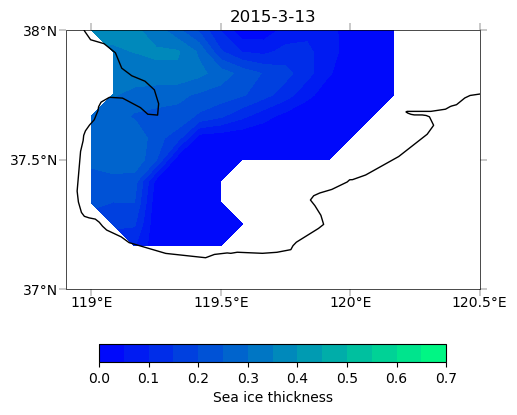

In [1]:

import datetime
import pandas as pd
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
from os import listdir
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
das=nc.Dataset(r'C:\Users\XUEX\Downloads\cmems_mod_glo_phy_my_0.083_P1D-m_1684240726046.nc')
def cftime2pdtime(cf):
    return pd.to_datetime(datetime.datetime(cf.year,cf.month,cf.day,cf.hour))
time=pd.to_datetime(list(map(cftime2pdtime,nc.num2date(das['time'],das['time'].units))))
sithick=np.array(das['sithick'])
sithick[sithick<-100]=np.nan
lon=np.array(das['longitude'])
lat=np.array(das['latitude'])
time_n=time[np.nansum(np.nansum(sithick,axis=-1),axis=-1)>0]
num=158
#plt.figure(figsize=[12.5,10])
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180),)
Lon,Lat=np.meshgrid(lon,lat,)
c=ax.contourf(Lon,Lat,sithick[time==time_n[num],:,:][0,:,:],np.arange(0,0.71,0.05),cmap='winter',transform=ccrs.PlateCarree(central_longitude=0))
ax.contourf(Lon,Lat,sithick[time==time_n[num],:,:][0,:,:],[0.7,99],colors=['#00fc81'],transform=ccrs.PlateCarree(central_longitude=0))
ax.xaxis.set_major_formatter(LongitudeFormatter())#刻度格式转换为经纬度样式 
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))#刻度格式转换为经纬度样式 
ax.yaxis.set_minor_locator(mticker.MultipleLocator(5))
ax.tick_params(axis='both',which='major',labelsize=10,direction='out',length=5,width=0.3,pad=0.2,top=True,right=True)
ax.coastlines() 
ax.spines['geo'].set_linewidth(0.5)#调节边框粗细
ax.set_xticks(np.arange(int(np.nanmin(Lon)),int(np.nanmax(Lon)+1),0.5)-180)
ax.set_yticks(np.arange(int(np.nanmin(Lat)-1),int(np.nanmax(Lat)+1),0.5))
ax.set_ylim(37,38)
ax.set_xlim(118.9-180,120.5-180)
ax.set_title(label=f'{time[time==time_n[num]].year[0]}-{time[time==time_n[num]].month[0]}-{time[time==time_n[num]].day[0]}')
#plt.grid()
plt.colorbar(c,orientation='horizontal',label=das['sithick'].long_name,shrink=0.7)
plt.show()

'Ice concentration'

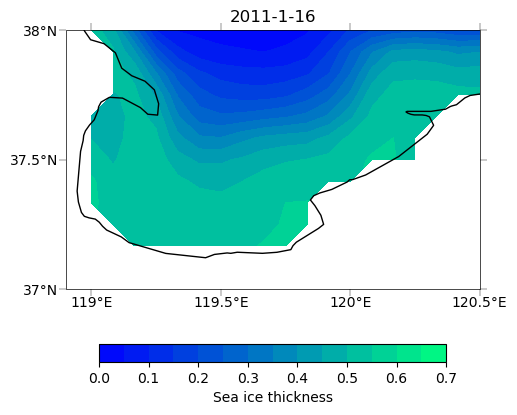

In [122]:
sithick=np.array(das['sithick'])
sithick[sithick<-100]=np.nan

lon=np.array(das['longitude'])
lat=np.array(das['latitude'])
time_n=time[np.nansum(np.nansum(sithick,axis=-1),axis=-1)>0]
num=15
#plt.figure(figsize=[12.5,10])
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180),)
Lon,Lat=np.meshgrid(lon,lat,)
c=ax.contourf(Lon,Lat,sithick[time==time_n[num],:,:][0,:,:],np.arange(0,0.71,0.05),cmap='winter',transform=ccrs.PlateCarree(central_longitude=0))
ax.contourf(Lon,Lat,sithick[time==time_n[num],:,:][0,:,:],[0.7,99],colors=['#00fc81'],transform=ccrs.PlateCarree(central_longitude=0))
ax.xaxis.set_major_formatter(LongitudeFormatter())#刻度格式转换为经纬度样式 
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))#刻度格式转换为经纬度样式 
ax.yaxis.set_minor_locator(mticker.MultipleLocator(5))
ax.tick_params(axis='both',which='major',labelsize=10,direction='out',length=5,width=0.3,pad=0.2,top=True,right=True)
ax.coastlines() 
ax.spines['geo'].set_linewidth(0.5)#调节边框粗细
ax.set_xticks(np.arange(int(np.nanmin(Lon)),int(np.nanmax(Lon)+1),0.5)-180)
ax.set_yticks(np.arange(int(np.nanmin(Lat)-1),int(np.nanmax(Lat)+1),0.5))
ax.set_ylim(37,38)
ax.set_xlim(118.9-180,120.5-180)
ax.set_title(label=f'{time[time==time_n[num]].year[0]}-{time[time==time_n[num]].month[0]}-{time[time==time_n[num]].day[0]}')
#plt.grid()
plt.colorbar(c,orientation='horizontal',label=das['sithick'].long_name,shrink=0.7)
plt.show()

In [112]:
ax.get_xlim()

(-62.0, -58.5)